In [1]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import datetime
import utils

In [32]:
def bucket_analysis(df, timeframe, target):
    df_agg, df_IQR_agg = utils.aggregate_by_time(df,'bucket_'+timeframe+'min',target)
    
    utils.bar_by_time(df_agg,'mean',timeframe+' Minute Interval', 'Average '+target)
    utils.bar_by_time(df_agg,'std',timeframe+' Minute Interval', 'STD of '+target)
    
    utils.bar_by_time(df_IQR_agg,'mean',timeframe+' Minute Interval', 'Average IQR '+target)
    utils.bar_by_time(df_IQR_agg,'std',timeframe+' Minute Interval', 'STD of IQR '+target)

In [34]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [35]:
query_min = "SELECT * FROM gold.active_1min"
df_min = pd.read_sql(query_min,engine)

In [36]:
df_min['bucket_30min'] = df_min['bar_time'].apply(
    lambda t: (
        datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60 + t.minute)//30 *30)  
    ).time() 
)
df_min['bucket_15min'] = df_min['bar_time'].apply(
    lambda t: (
        datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60 + t.minute)//15 *15)  
    ).time() 
)
df_min['bucket_5min'] = df_min['bar_time'].apply(
    lambda t: (
        datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60 + t.minute)//5 *5)  
    ).time() 
)

In [37]:
df_min['price_movement'] = (df_min['high']-df_min['low']).abs()
df_day = df_min.groupby('bar_date')['price_movement'].agg('sum').reset_index()
df_30 = df_min.groupby(['bar_date','bucket_30min'])['price_movement'].agg('sum').reset_index()
df_15 = df_min.groupby(['bar_date','bucket_15min'])['price_movement'].agg('sum').reset_index()
df_5 = df_min.groupby(['bar_date','bucket_5min'])['price_movement'].agg('sum').reset_index()

Daily Analysis

In [6]:
utils.get_basic_info(df_day,'price_movement')

count     229.000000
mean     1356.941048
std       875.307329
min        99.750000
25%       840.500000
50%      1154.500000
75%      1575.250000
max      7495.250000
Name: price_movement, dtype: float64
Median:  1154.5
Std Dev:  875.3073290583616
IQR: 734.75


In [7]:
df_day[df_day['price_movement']<500]

,bar_date,price_movement
118,2025-07-01,99.75
120,2025-07-03,420.25


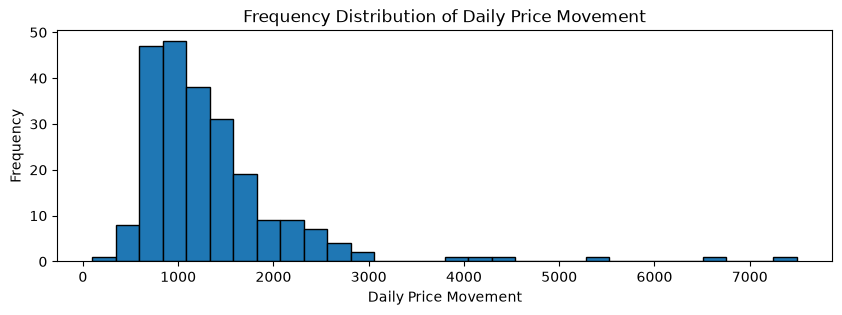

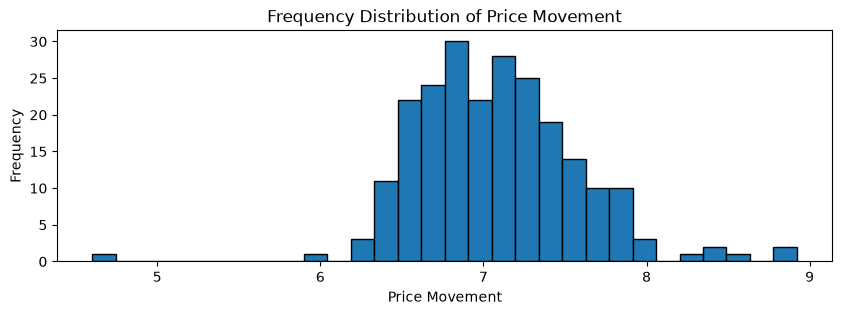

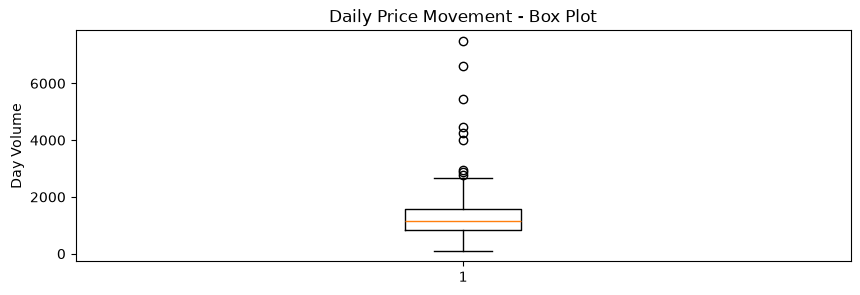

In [8]:
utils.frequency_hist(df_day,'price_movement',30,'Daily Price Movement')

df_day['log_price_movement'] = np.log(df_day['price_movement'])
utils.frequency_hist(df_day,'log_price_movement',30,'Price Movement')

utils.box_plot(df_day,'price_movement','Day Volume', 'Daily Price Movement - Box Plot')

30 Minute Analysis

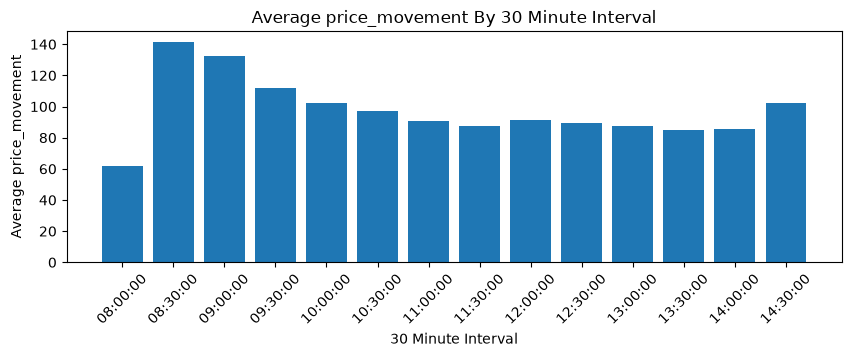

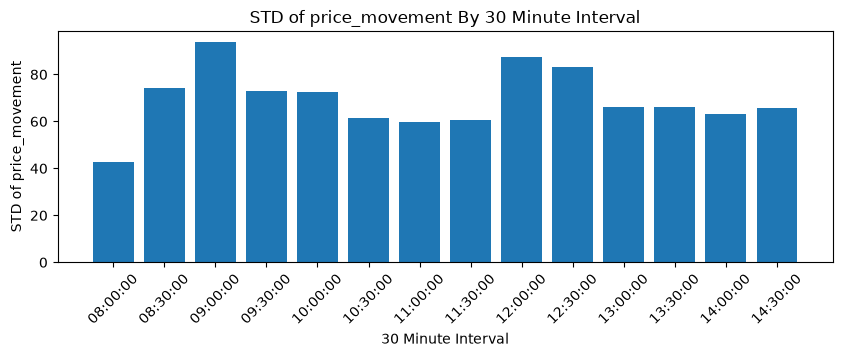

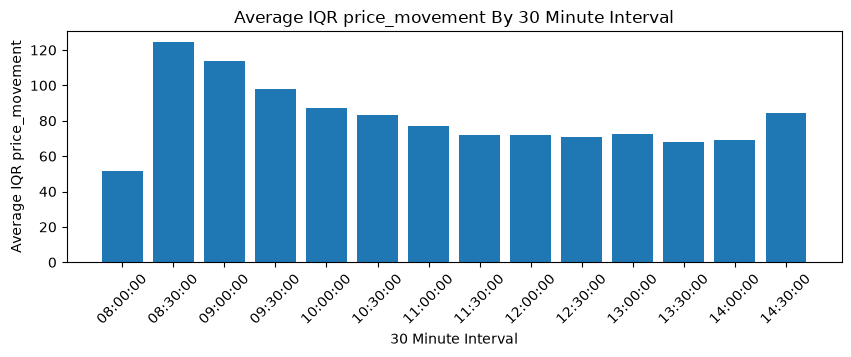

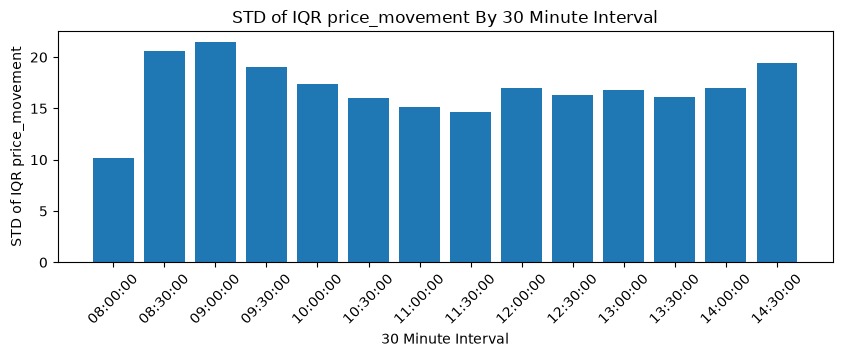

In [38]:
bucket_analysis(df_30,'30','price_movement')

15-Minute Analysis

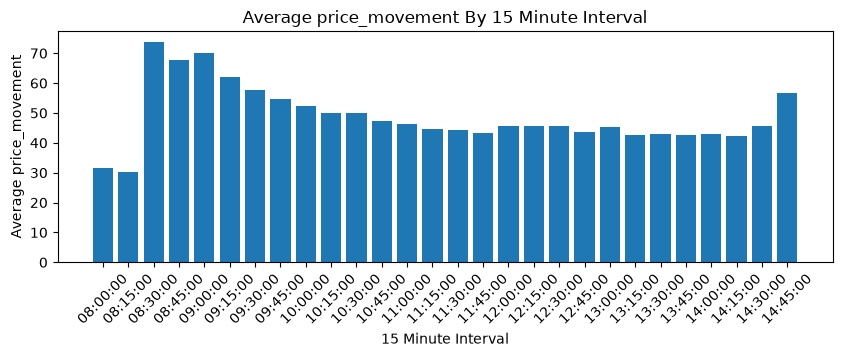

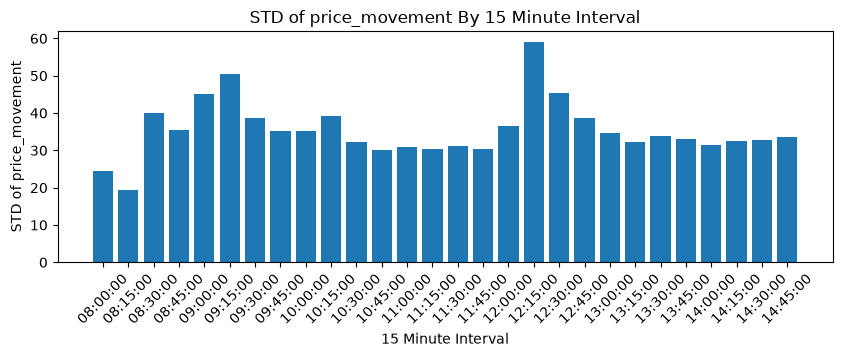

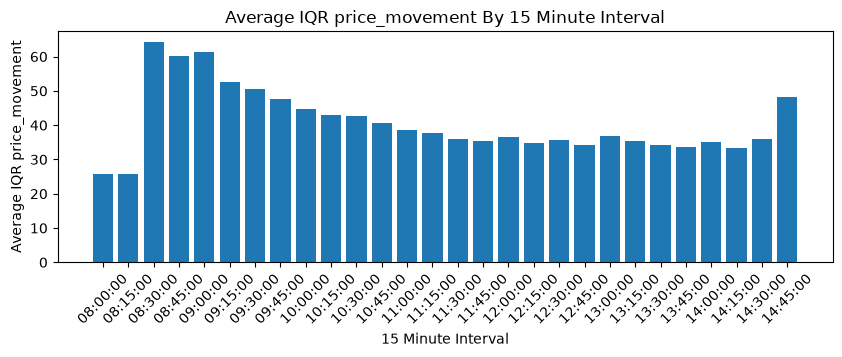

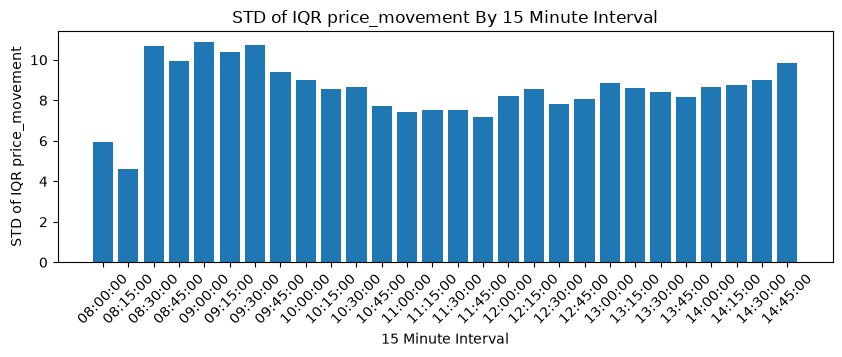

In [41]:
bucket_analysis(df_15,'15','price_movement')

5-Minute Analysis

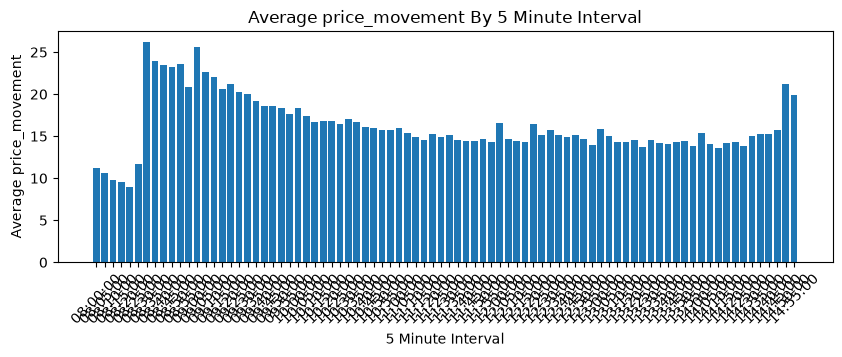

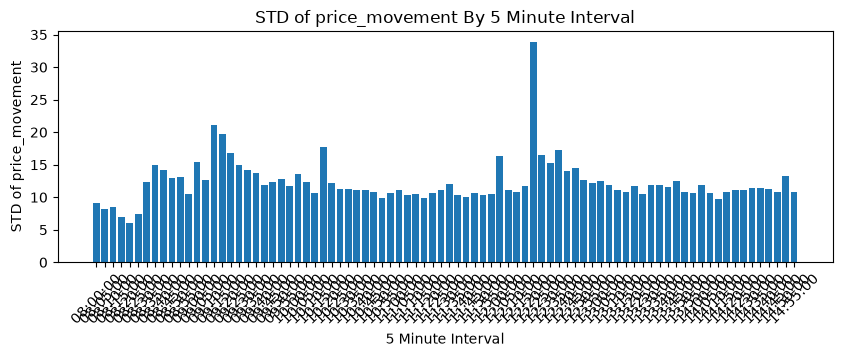

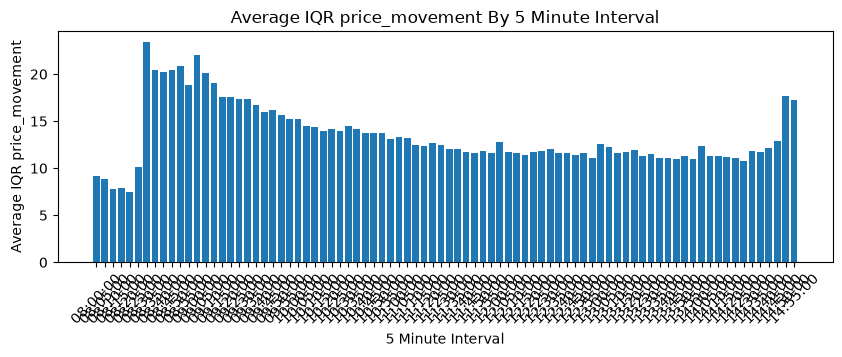

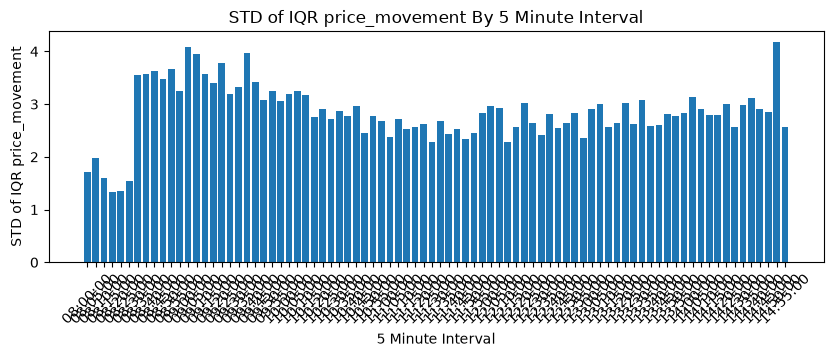

In [42]:
bucket_analysis(df_5,'5','price_movement')